# Evaluating latent variation

This tutorial demonstrates how to evaluate a **DeepDive** model and iteratively incorporate previously unmodeled sources of variation through a second training pass.

---

## Imports

In [1]:
import scanpy as sc
import DeepDive

In [2]:
from utils import reads_to_fragments

## 1. Load and preprocess the dataset

We begin with an `AnnData` object containing single-cell chromatin accessibility profiles. In this example, we use a liver dataset (`sciatac3_liver_10k.h5ad`), which consists of 10,000 cells sampled from the [sciATAC-seq3](https://doi.org/10.1126/science.aba7612) dataset.

Preprocessing steps are described in more detail in the [Training a DeepDive Model](https://deepdive-tutorial.readthedocs.io/en/latest/tutorials/Training.html#) tutorial.

In [3]:
adata = sc.read_h5ad('data/sciatac3_liver_10k.h5ad')

In [4]:
min_cells = int(adata.shape[0] * 0.01)
sc.pp.filter_genes(adata, min_cells=min_cells)

In [5]:
adata.obs_names_make_unique()
reads_to_fragments(adata)
adata.X = adata.layers['fragments']


## 2. Train the model

We initialize and train a DeepDive model using known covariates. These include both discrete variables (e.g., sample, sex, batch) and continuous variables (e.g., day of pregnancy).

In [6]:
n_decoders = 1  
model_params = {
    'n_epochs_pretrain_ae' : 200*n_decoders,
    'n_decoders' : n_decoders,
}
train_params = {
    'max_epoch' : 300*n_decoders, 
    'batch_size' : 1024, 
    'shuffle' : True
}

In [7]:
discrete_covriate_keys = ['sample_name', 'sex', 'batch']
continuous_covriate_keys = ['day_of_pregnancy']

In [8]:
model = DeepDive.DeepDive(adata = adata, 
                        discrete_covariate_names = discrete_covriate_keys,
                        continuous_covariate_names = continuous_covriate_keys, 
                        **model_params
                       )

In [9]:
model.train_model(adata, None, 
                  **train_params)

Epoch Train [300 / 300]: 100%|██████████| 10/10 [00:00<00:00, 13.03it/s, ETA=01d:00h:03:m26s|01d:00h:03:m26s, kl_loss=5.44, recon_loss=3.19e+3]


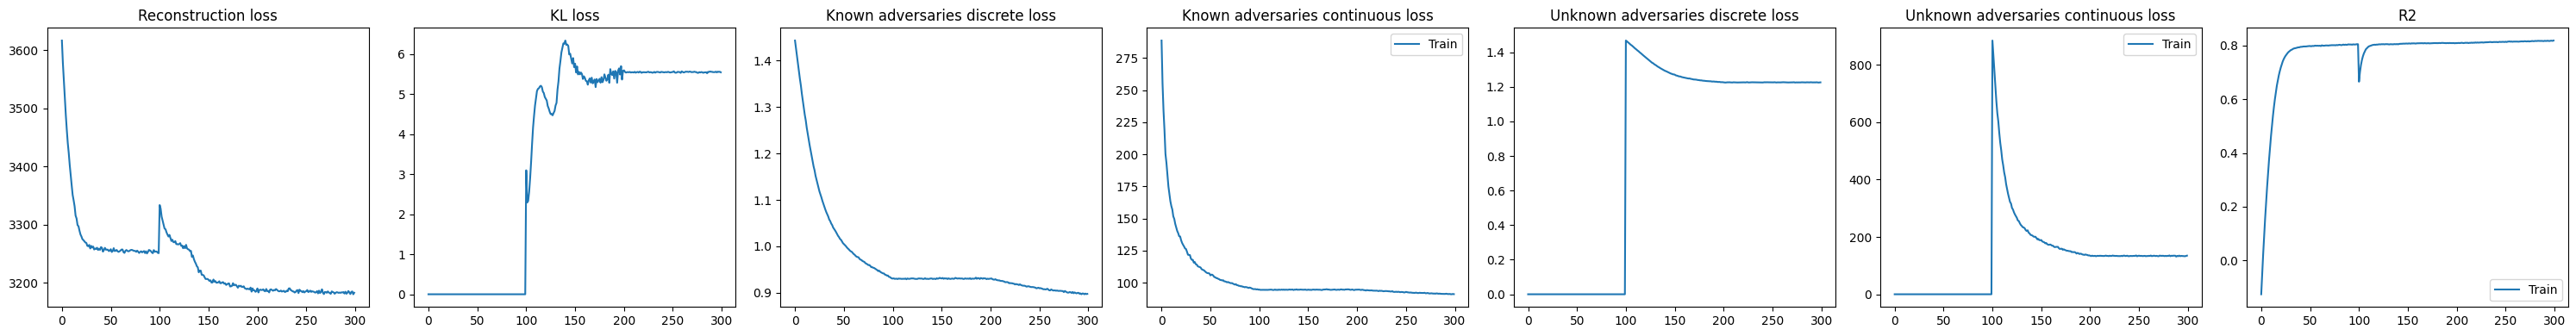

In [10]:
DeepDive.plot_history(model)

The KL divergence remains relatively high, suggesting that substantial variation is still being captured in the residual (unknown) component of the model. This indicates that not all sources of structure in the data are explained by the provided covariates, and that additional biological or technical factors may still be influencing chromatin accessibility.

## 3. Evaluate latent variation

To assess whether unmodeled sources of variation influence chromatin accessibility, we examine the learned latent representation.

Here, we compute the latent embedding without adding additional covariates and visualize it using UMAP. Clustering in this space may indicate residual structure not explained by the specified covariates.

In [11]:
latent = model.get_latent(adata, covars_to_add=[])

In [12]:
sc.pp.neighbors(latent)

In [13]:
sc.tl.umap(latent)

In [14]:
sc.tl.leiden(latent, resolution = 0.2)

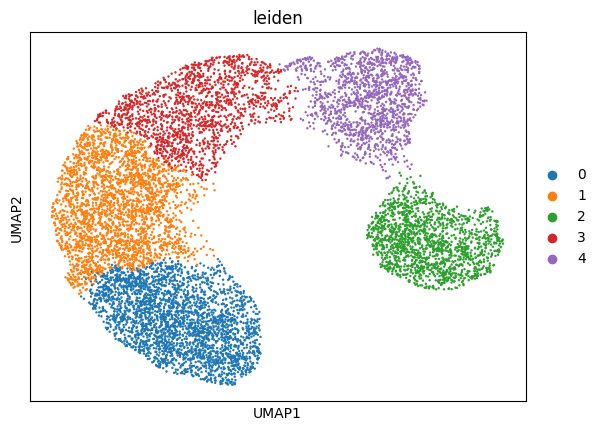

In [15]:
sc.pl.umap(latent, color = 'leiden')

## 4. Incorporate residual variation and retrain the model

To account for previously unmodeled variation, we use the clusters identified in the latent space (e.g., Leiden clusters) as an additional covariate.

We then retrain the DeepDive model with this new covariate and re-evaluate the latent space. This iterative approach helps disentangle structured biological or technical variation that was not captured in the initial model.

In [16]:
adata.obs['Residual_first_pass'] = latent.obs['leiden']

In [17]:
discrete_covriate_keys = discrete_covriate_keys + ['Residual_first_pass']


In [18]:
model = DeepDive.DeepDive(adata = adata, 
                        discrete_covariate_names = discrete_covriate_keys,
                        continuous_covariate_names = continuous_covriate_keys, 
                        **model_params
                       )

In [19]:
model.train_model(adata, None, 
                  **train_params)

Epoch Train [300 / 300]: 100%|██████████| 10/10 [00:00<00:00, 11.18it/s, ETA=01d:00h:03:m55s|01d:00h:03:m55s, kl_loss=1.5, recon_loss=3.18e+3] 


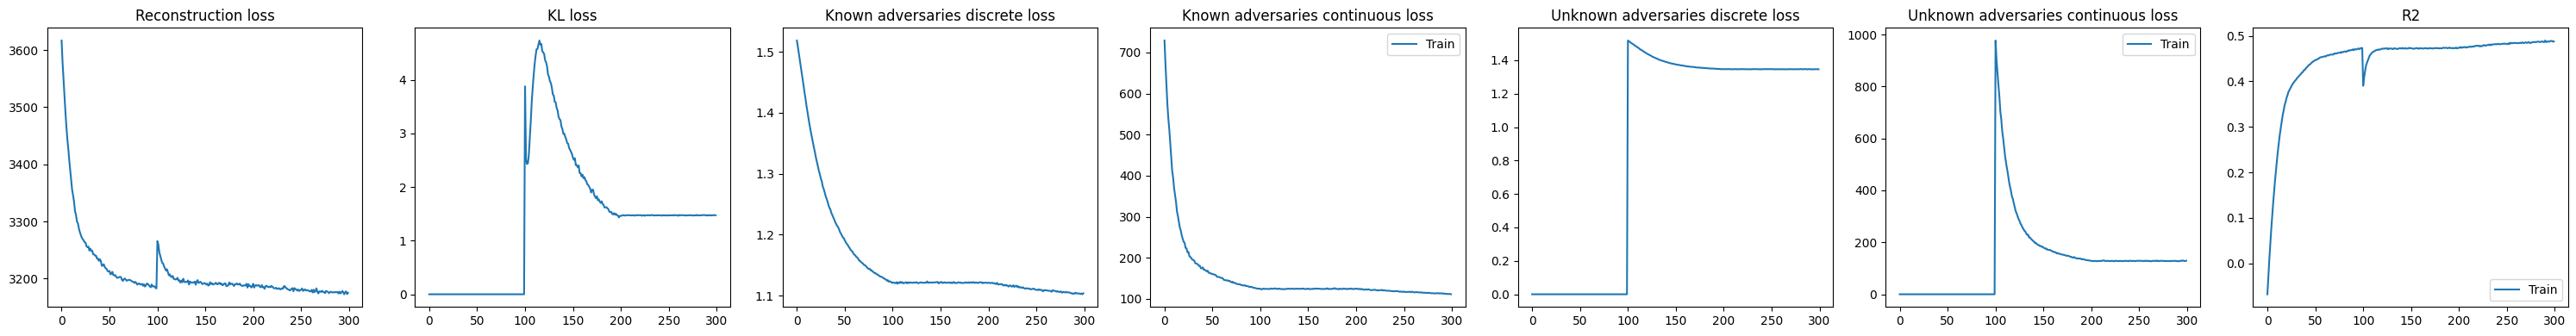

In [20]:
DeepDive.plot_history(model)

Following retraining, the KL divergence decreases, indicating that previously unexplained variation is now captured by the added covariate.

In [21]:
latent = model.get_latent(adata, covars_to_add=[])

In [22]:
sc.pp.neighbors(latent)

In [23]:
sc.tl.umap(latent)

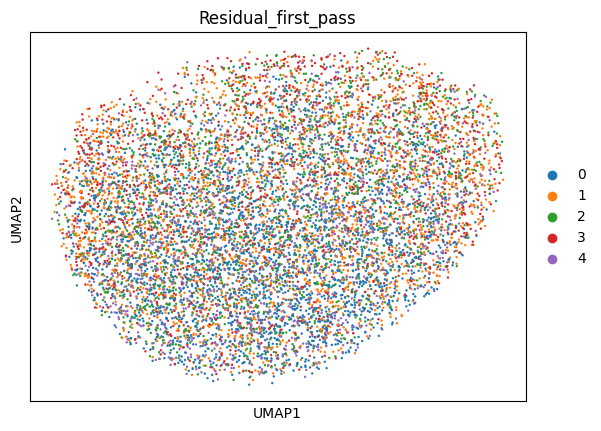

In [24]:
sc.pl.umap(latent, color = ['Residual_first_pass'])